In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
print(os.getpid())
sys.path.append(os.path.abspath("./"))
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

import pylib.Chebyschev_coefs as ch

import stepanoff

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

16504
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_save_      = "./jupyter-notebooks/Stepanoff/results/"
path_qucf_root_ = "../QuCF/simulations/Stepanoff/"
for i in range(100):
    plt.close()

In [3]:
# -------------------------------------------------------------------
# --- Main parameters ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
# -----------------------------------------------------
# --- Parameters for temporal and spatial grids ---
# Total time interval is dt_ * Nt_
# -----------------------------------------------------------------
# Here, rr_init_ takes into account AA of the initialization     
# rr_init_ is computed in ./init_mod_QSVT.ipynb by comparing of  
# the QuCF simulation of the non-amplified initial condition and 
# the QuCF simulation of the amplified initial condition     
# -----------------------------------------------------------------    


# --- These parameters were used for amplitude estimation ---
dt_, Nt_ = 0.1, 10
nx_, rr_init_, flag_norm_max_ = 6, 3.216984647198e+00, False
# nx_, rr_init_, flag_norm_max_ = 8, 3.221144236543e+00, False

# --- other parameters ---
alpha_ = np.sqrt(20.)
kappa_ = 1.
file_qucf_ = "sim"

# path_qucf_ = path_qucf_root_ + "/sim_diag_dt{:0.3f}".format(dt_)
path_qucf_ = path_qucf_root_ + "/sim_diag_dt{:0.3f}_AE".format(dt_)

# --- spatial grid ---
Nx_ = 1 << nx_
nx_half_ = nx_ - 1
Nx_half_ = 1 << nx_half_
x_ = np.linspace(0., 2.*np.pi, Nx_)

# --- unitary operators ---
init_2d_    = stepanoff.f_init_2d(kappa_, x_, Nx_)
diag_U_M1_  = stepanoff.create_diag_matrix(dt_, Nx_half_, alpha_, "M1", True)
diag_U_M2_  = stepanoff.create_diag_matrix(dt_, Nx_half_, alpha_, "M2", True)

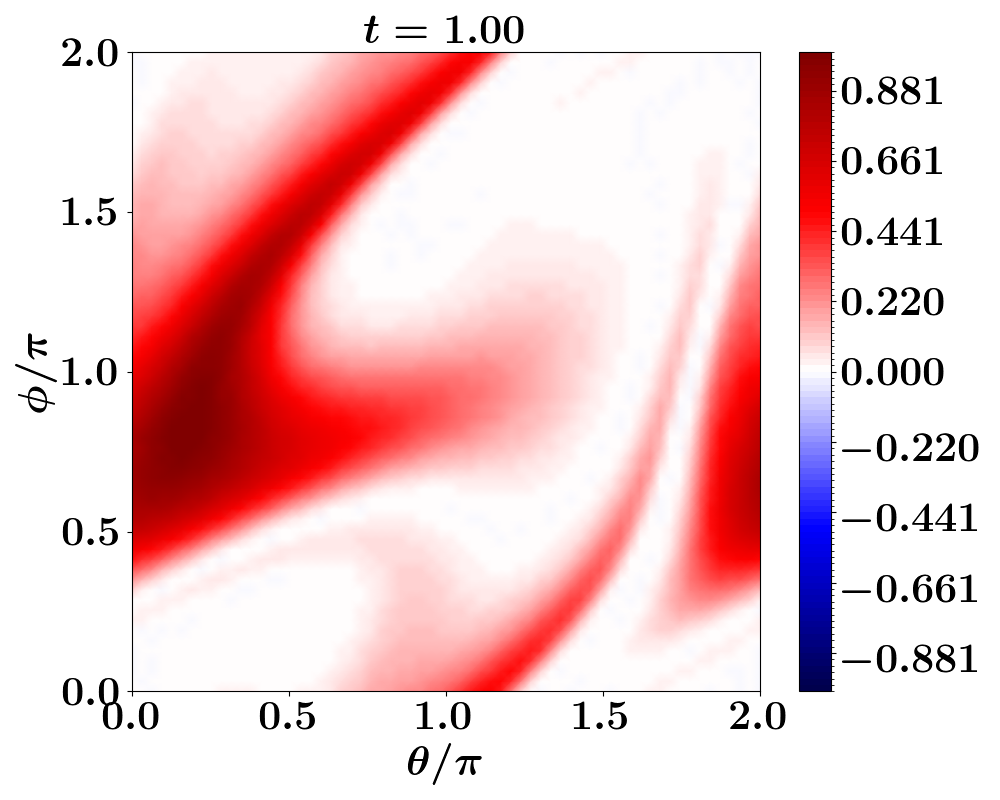

In [4]:
# -------------------------------------------------------------------
# --- Classical simulations in real-Fourier space  ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
y_cl_mod_mix_, y_cl_mix_ = stepanoff.computation_in_real_and_fourier(
    dt_, Nt_, x_,
    diag_U_M1_, diag_U_M2_, init_2d_,
    flag_plot = True,
    flag_norm_max = flag_norm_max_
)

In [5]:
# -------------------------------------------------------------------
# --- Classical simulations in real space  ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
y_cl_dopri_ = stepanoff.get_Dopri_classical_simulations(
    dt_, Nt_, x_,
    alpha_, kappa_,
    path_save = path_save_,
    prefix = "new_", 
    flag_plot = False,
    flag_norm_max = flag_norm_max_
)

--- Looking for the file: new_Stepanoff_data_k1.0_a4.472_n6.hdf5 in the path ./jupyter-notebooks/Stepanoff/results/
--- Loading data ---
Reading the coefficients from:
 ./jupyter-notebooks/Stepanoff/results/new_Stepanoff_data_k1.0_a4.472_n6.hdf5

Take the Dopri simulation at t = 1


In [7]:
# -------------------------------------------------------------------
# --- Functions for computing observables directly ---
# -------------------------------------------------------------------
def compute_observable_cos_phi_(psi_mod, line_str):
    Nx = np.shape(psi_mod)[0]
    res_v = 0.
    for i_phi in range(Nx):
        for i_theta in range(Nx):
            res_v += np.abs(psi_mod[i_theta, i_phi])**2 * np.cos(i_phi)**2
    res_v /= Nx**2
    print("cos-phi: {:s}: {:0.3e}".format(line_str, res_v))
    return res_v


Reading the file ../QuCF/simulations/Stepanoff//sim_diag_dt0.100_AE/sim_nx6_t1_OUTPUT.hdf5...
Reading probabilities for the initial conditions 0.
Name of the simulation is sim
Simulation has been performed  07-24-2025 19:02:01

A-max: 2.205175081580e-03
success prob: 1.304e-03
N-gates: 8260414
max. abs. err (mix  space): 9.796e-01
max. abs. err (real space): 9.904e-01

--- Observables ---
cos-phi: CL: 5.048e-02
cos-phi: QC-DIR: 6.577e-05
------------------------------------------



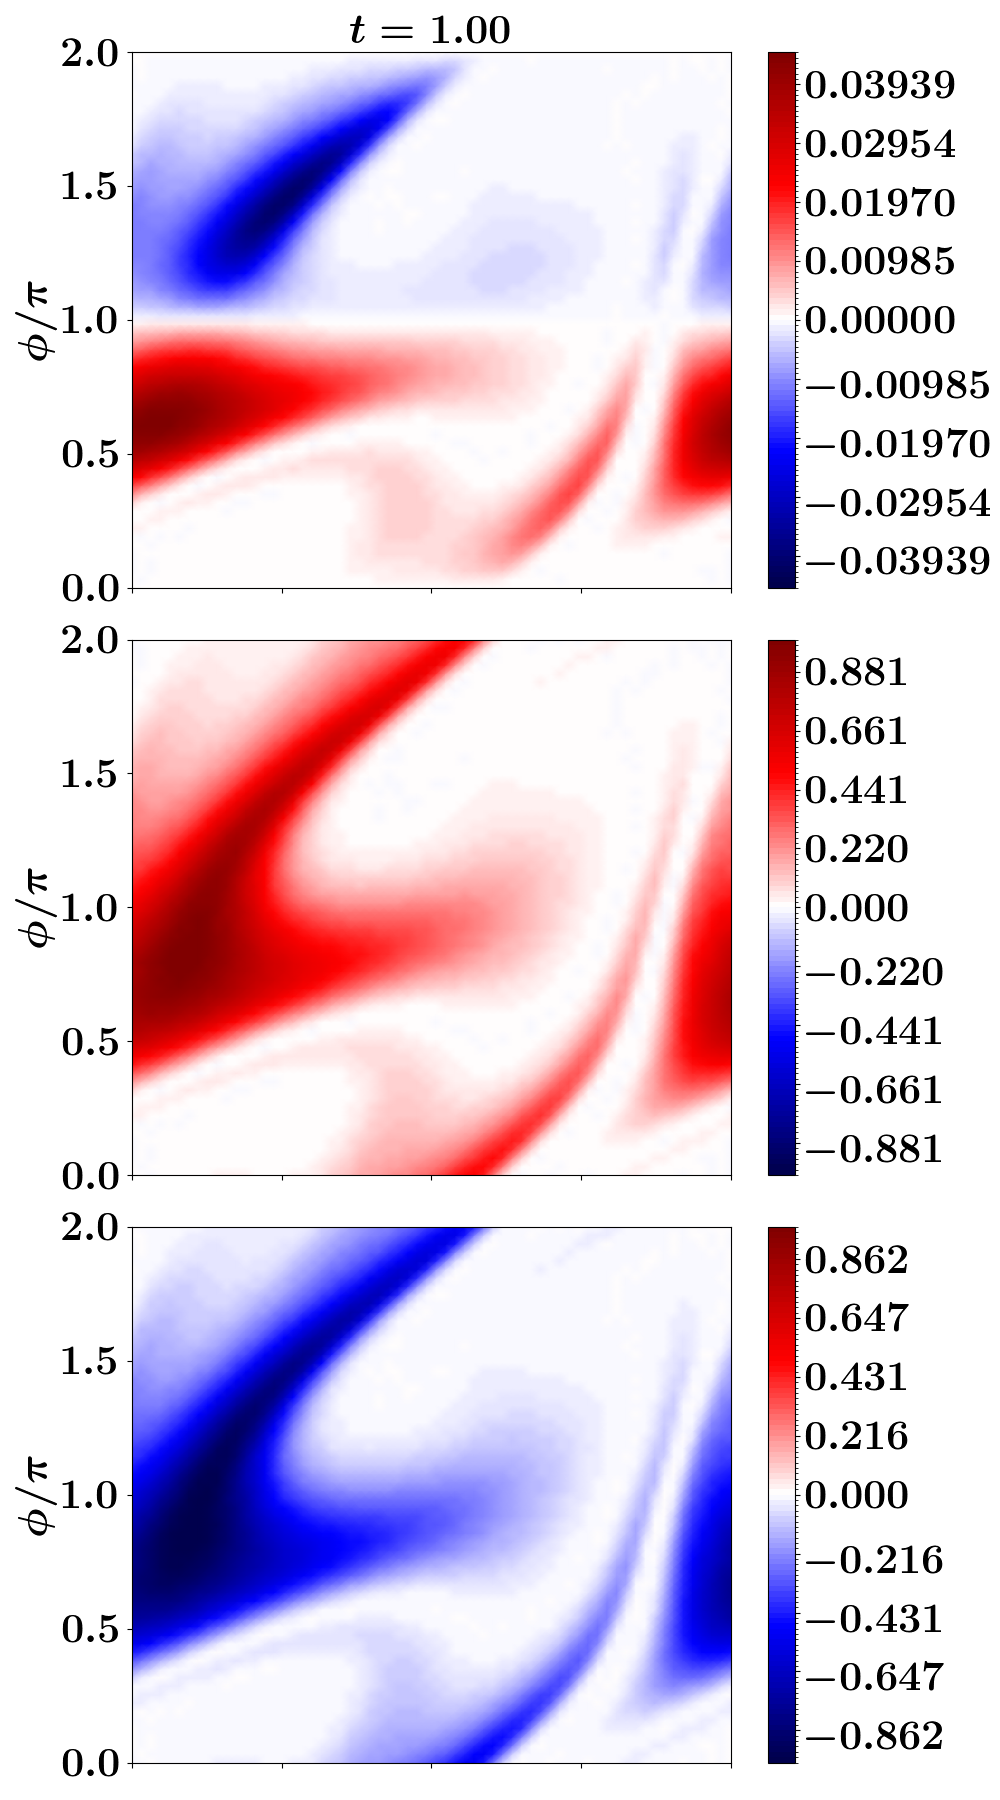

In [8]:
# -------------------------------------------------------------------
# --- Compare classical and QuCF results ---
# -------------------------------------------------------------------
mix.reload_module(mix)
mix.reload_module(stepanoff)
def read_qc_data(path_qc, name_file_qc):
    print()  

    # --- Read the _OUTPUT.hdf5 file ---
    om = mse.MeasOracle__()
    om.path_  = path_qc
    om.pname_ = name_file_qc
    om.open()
    
    # --- get the result ---
    Ngates = om.dd_["N-gates"]
    om.set_zero_ancillae_work_states(0)
    qc_state = om.get_var_x({}, "r")

    resc_coef = 1.
    if not flag_norm_max_:
        om.read_qsvt()
        resc_qsvt = om.dd_["init"]["rescaling_factor"]
        Hadamart_norm_factor = 2.**(nx_//2)
        resc_coef = (Hadamart_norm_factor / resc_qsvt)**2 / rr_init_
    print()
    print("A-max: {:0.12e}".format(np.max(np.abs(qc_state))))
    print("success prob: {:0.3e}".format(  np.sum(np.abs(qc_state)**2)  ))
    print("N-gates: {:d}".format(Ngates))

    qc_state *= resc_coef
    return qc_state
# -------------------------------------------------------------------
def compare_classical_qucf(
        y_cl_mod_mix, y_cl_mix, y_cl_dopri, 
        path_qucf, file_qucf,
        compute_observable,
        flag_plot
    ):
    # --- QuCF data ---
    psi_qc_1d = read_qc_data(path_qucf, file_qucf)

    psi_qc_1d_real = psi_qc_1d.real
    psi_qc_2d = stepanoff.rearrange_into_2d(psi_qc_1d_real, Nx_)

    # --- Change of coordinates back to the original ---
    y_res_qc = stepanoff.change_coord_to_orig(psi_qc_2d, Nx_)

    if flag_norm_max_:
        y_res_qc /= np.max(np.abs(y_res_qc)) 

    # --- Error ---
    err_mix = y_res_qc - y_cl_mix
    max_abs_err_mix = np.max(np.abs(err_mix))

    err_real = y_res_qc - y_cl_dopri
    max_abs_err_real = np.max(np.abs(err_real))

    print("max. abs. err (mix  space): {:0.3e}".format(max_abs_err_mix))
    print("max. abs. err (real space): {:0.3e}".format(max_abs_err_real))

    # --- Compare observables ---
    print("\n--- Observables ---")
    compute_observable(y_cl_mod_mix,            "CL")
    compute_observable(np.transpose(psi_qc_2d), "QC-DIR")
    print("------------------------------------------\n")

    # --- Plotting ---
    if flag_plot:
        X, Y = np.meshgrid(x_/np.pi, x_/np.pi)
        # fig1, axs = plt.subplots(4, 1, figsize=(10,24))
        fig1, axs = plt.subplots(3, 1, figsize=(10,18))
        stepanoff.plot_2D_subplot(
            axs[0], fig1, X, Y, y_res_qc,  
            str_title="$" + "t={:0.2f}".format(Nt_*dt_) + "$", 
            label_x = '', label_y = "$\phi/\pi$", 
            flag_x = False
        )
        stepanoff.plot_2D_subplot(
            axs[1], fig1, X, Y, y_cl_mix,  
            label_x = '', label_y = "$\phi/\pi$", 
            flag_x = False
        )
        stepanoff.plot_2D_subplot(
            axs[2], fig1, X, Y, err_mix,   
            label_x = '', label_y = "$\phi/\pi$",
            flag_x = False
        )
        # stepanoff.plot_2D_subplot(
        #     axs[4], fig1, X, Y, y_cl_dopri,  
        #     label_x = '', label_y = "$\phi/\pi$", 
        #     flag_x = False
        # )
        # stepanoff.plot_2D_subplot(
        #     axs[5], fig1, X, Y, err_real,  
        #     label_x = '$\\theta/\pi$', label_y = "$\phi/\pi$"
        # )
        plt.tight_layout()
    return
# ----------------------------------------------------------------------
file_output = "sim_nx{:d}_t{:d}".format(nx_, int(Nt_*dt_))

compare_classical_qucf(
    y_cl_mod_mix_, y_cl_mix_, y_cl_dopri_, 
    path_qucf_, file_output,
    compute_observable_cos_phi_,
    flag_plot = True
)